In [1]:
import fastf1.plotting
import matplotlib.pyplot as plt

# FastF1's dark color scheme
fastf1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme="fastf1")

session = fastf1.get_session(2025, 23, "Q")
session.load()

req         WARNING 	DEFAULT CACHE ENABLED! (611.82 MB) C:\Users\Vitor\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Qatar Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '1', '63', '12', '6', '55', '14', '10', '16', '27', '30', '87', '5', '23', '22', '31', '44', '18', '43']


In [2]:
pia_lap = session.laps.pick_drivers("PIA").pick_fastest()
ver_lap = session.laps.pick_drivers("VER").pick_fastest()

In [3]:
pia_tel = pia_lap.get_car_data().add_distance()
ver_tel = ver_lap.get_car_data().add_distance()

req            INFO 	Using cached data for driver_info


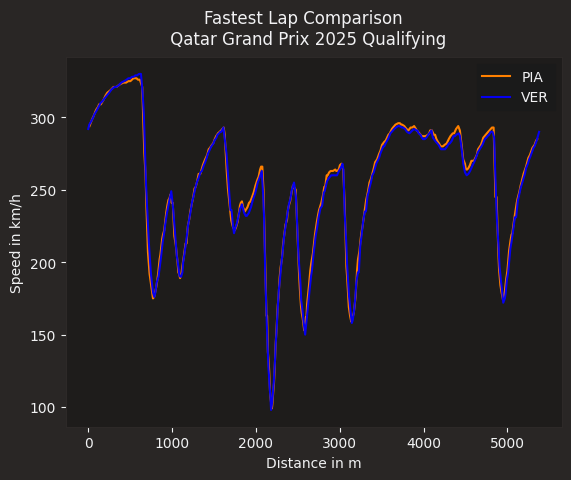

In [7]:
mcl_color = fastf1.plotting.get_team_color(pia_lap["Team"], session=session)
rbr_color = fastf1.plotting.get_team_color(ver_lap["Team"], session=session)

fig, ax = plt.subplots()
ax.plot(pia_tel["Distance"], pia_tel["Speed"], color=mcl_color, label="PIA")
ax.plot(ver_tel["Distance"], ver_tel["Speed"], color=rbr_color, label="VER")

ax.set_xlabel("Distance in m")
ax.set_ylabel("Speed in km/h")

ax.legend()
plt.suptitle(f"Fastest Lap Comparison \n "
             f"{session.event['EventName']} {session.event.year} Qualifying")

plt.show()